# 1. Préparation des données
### Train / validation / test split
### Normalisation des features
### Encodage si nécessaire

## Importer les bibliothèques et charger le dataset
On charge le fichier openfoodfacts_cleaned.csv et on affiche un aperçu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset réel
file_path = 'openfoodfacts_cleaned.csv'
df = pd.read_csv(file_path)
df.head()

C:\Users\riqwi\AppData\Local\Temp\ipykernel_22676\843001492.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Unnamed: 0,generic_name,quantity,brands,categories_en,origins_en,countries_en,traces_en,additives_n,additives_en,...,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,3,NaN,480 g,Danone,"Dairies,Fermented foods,Fermented milk product...",NaN,France,NaN,NaN,NaN,...,10.0,0.09,0.036,NaN,NaN,NaN,NaN,NaN,NaN,-5.0
1,4,NaN,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,...,7.8,1.40,0.560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,NaN,NaN,NaN,NaN,NaN,Spain,NaN,NaN,NaN,...,15.7,2.10,0.840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,NaN,NaN,NaN,NaN,NaN,United States,NaN,NaN,NaN,...,0.0,0.00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,NaN,NaN,NaN,NaN,NaN,France,NaN,NaN,NaN,...,0.2,2.04,0.816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Nettoyage et préparation des données
- Suppression des colonnes inutiles
- Gestion des valeurs manquantes
- Normalisation des variables numériques
- Affichage des informations sur le dataset

In [2]:
# Suppression des colonnes inutiles (exemple: index, identifiants, colonnes texte longues inutiles)
colonnes_a_supprimer = [col for col in df.columns if 'Unnamed' in col or 'id' in col or 'code' in col]
df = df.drop(columns=colonnes_a_supprimer, errors='ignore')

# Gestion des valeurs manquantes :
# - Pour les variables numériques : imputation par la médiane
# - Pour les variables catégorielles : imputation par le mode
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982824 entries, 0 to 1982823
Data columns (total 34 columns):
 #   Column                                                 Dtype  
---  ------                                                 -----  
 0   generic_name                                           object 
 1   quantity                                               object 
 2   brands                                                 object 
 3   categories_en                                          object 
 4   origins_en                                             object 
 5   countries_en                                           object 
 6   traces_en                                              object 
 7   additives_n                                            float64
 8   additives_en                                           object 
 9   nutriscore_score                                       float64
 10  food_groups_en                                         object 
 11

,generic_name,quantity,brands,categories_en,origins_en,countries_en,traces_en,additives_n,additives_en,nutriscore_score,...,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g
0,Pâtes alimentaires de qualité supérieure,480 g,Danone,"Dairies,Fermented foods,Fermented milk product...",France,France,Nuts,1.0,E330 - Citric acid,-5.0,...,10.0,0.09,0.036,0.0,0.0,0.173,0.04,0.00101,0.41875,-5.0
1,Pâtes alimentaires de qualité supérieure,500 g,Carrefour,Snacks,France,France,Nuts,1.0,E330 - Citric acid,9.0,...,7.8,1.40,0.560,0.0,0.0,0.173,0.04,0.00101,0.41875,9.0
2,Pâtes alimentaires de qualité supérieure,500 g,Carrefour,Snacks,France,Spain,Nuts,1.0,E330 - Citric acid,9.0,...,15.7,2.10,0.840,0.0,0.0,0.173,0.04,0.00101,0.41875,9.0
3,Pâtes alimentaires de qualité supérieure,500 g,Carrefour,Snacks,France,United States,Nuts,1.0,E330 - Citric acid,9.0,...,0.0,0.00,0.000,0.0,0.0,0.173,0.04,0.00101,0.41875,9.0
4,Pâtes alimentaires de qualité supérieure,500 g,Carrefour,Snacks,France,France,Nuts,1.0,E330 - Citric acid,9.0,...,0.2,2.04,0.816,0.0,0.0,0.173,0.04,0.00101,0.41875,9.0


## Analyse rapide des variables
Affichage de statistiques descriptives et visualisations pour vérifier la qualité des données préparées.

        additives_n  nutriscore_score  ecoscore_score  energy-kcal_100g  \
count  1.982824e+06      1.982824e+06    1.982824e+06      1.982824e+06   
mean   1.378868e+00      8.957055e+00    4.882479e+01      7.161504e+09   
std    1.811011e+00      6.343197e+00    1.353111e+01      1.008431e+13   
min    0.000000e+00     -1.500000e+01   -3.000000e+01      0.000000e+00   
25%    1.000000e+00      9.000000e+00    4.900000e+01      1.140000e+02   
50%    1.000000e+00      9.000000e+00    4.900000e+01      2.680000e+02   
75%    1.000000e+00      1.000000e+01    4.900000e+01      4.030000e+02   
max    4.600000e+01      4.000000e+01    1.250000e+02      1.420000e+16   

           fat_100g  saturated-fat_100g  monounsaturated-fat_100g  \
count  1.982824e+06        1.982824e+06              1.982824e+06   
mean   1.507779e+01        5.248085e+00              3.642377e+00   
std    8.583571e+02        7.217128e+01              2.637621e+00   
min    0.000000e+00        0.000000e+00         

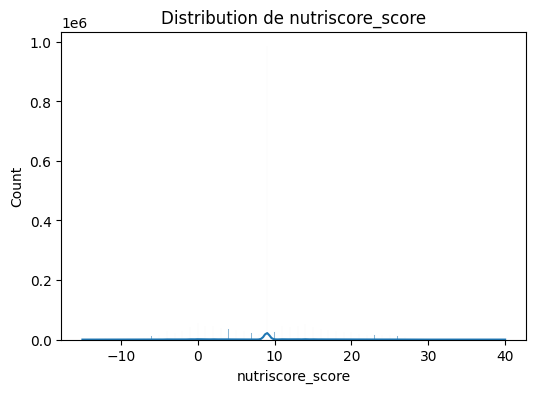

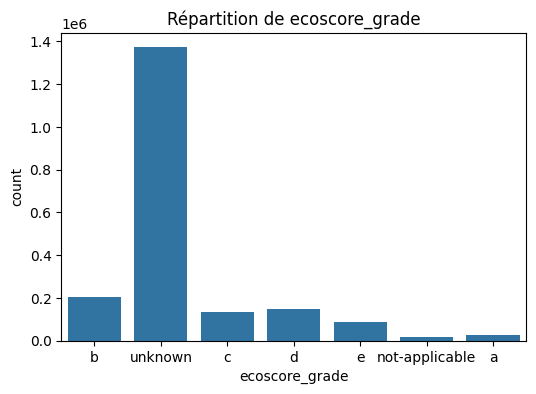

In [3]:
# Statistiques descriptives
print(df.describe())

# Visualisation d'une variable cible potentielle (ex: nutriscore_score si présente)
if 'nutriscore_score' in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df['nutriscore_score'], kde=True)
    plt.title('Distribution de nutriscore_score')
    plt.show()

# Visualisation d'une variable catégorielle (ex: ecoscore_grade)
if 'ecoscore_grade' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='ecoscore_grade', data=df)
    plt.title('Répartition de ecoscore_grade')
    plt.show()

## Split train / validation / test et encodage des variables catégorielles
On sépare le dataset, puis on encode uniquement les variables catégorielles à faible cardinalité (OneHotEncoder). Les colonnes à forte cardinalité sont supprimées.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Exemple : prédire nutriscore_score (régression)
target = 'nutriscore_score'  # Adapter la variable cible selon votre cas
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Split train/test (80/20), puis split train/validation (80/20 du train)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Encodage des variables catégorielles à faible cardinalité
max_modalites = 30
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_low_card = [col for col in cat_cols if X_train[col].nunique() <= max_modalites]
cat_high_card = [col for col in cat_cols if X_train[col].nunique() > max_modalites]

# Suppression des colonnes à forte cardinalité
X_train_enc = X_train.drop(columns=cat_high_card, errors='ignore').copy()
X_val_enc = X_val.drop(columns=cat_high_card, errors='ignore').copy()
X_test_enc = X_test.drop(columns=cat_high_card, errors='ignore').copy()

if cat_low_card:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_enc[cat_low_card])
    # Ajout des colonnes encodées
    X_train_ohe = encoder.transform(X_train_enc[cat_low_card])
    X_val_ohe = encoder.transform(X_val_enc[cat_low_card])
    X_test_ohe = encoder.transform(X_test_enc[cat_low_card])
    ohe_cols = encoder.get_feature_names_out(cat_low_card)
    import pandas as pd
    X_train_enc = pd.concat([X_train_enc.drop(columns=cat_low_card), pd.DataFrame(X_train_ohe, index=X_train_enc.index, columns=ohe_cols)], axis=1)
    X_val_enc = pd.concat([X_val_enc.drop(columns=cat_low_card), pd.DataFrame(X_val_ohe, index=X_val_enc.index, columns=ohe_cols)], axis=1)
    X_test_enc = pd.concat([X_test_enc.drop(columns=cat_low_card), pd.DataFrame(X_test_ohe, index=X_test_enc.index, columns=ohe_cols)], axis=1)

print(f"Colonnes supprimées (forte cardinalité) : {cat_high_card}")
print(f"Colonnes encodées (OneHot) : {cat_low_card}")
print(f"Train encodé: {X_train_enc.shape}, Validation encodée: {X_val_enc.shape}, Test encodé: {X_test_enc.shape}")

Train: (1269007, 33), Validation: (317252, 33), Test: (396565, 33)
Colonnes supprimées (forte cardinalité) : ['generic_name', 'quantity', 'brands', 'categories_en', 'origins_en', 'countries_en', 'traces_en', 'additives_en', 'food_groups_en', 'main_category_en']
Colonnes encodées (OneHot) : ['ecoscore_grade']
Train encodé: (1269007, 29), Validation encodée: (317252, 29), Test encodé: (396565, 29)


## Encodage des variables catégorielles
On ajuste l'encodeur sur le train, puis on applique la transformation à validation et test.

In [5]:
# Suppression des colonnes catégorielles à forte cardinalité (non encodées)
X_train_enc = X_train_enc.drop(columns=cat_high_card, errors='ignore')
X_val_enc = X_val_enc.drop(columns=cat_high_card, errors='ignore')
X_test_enc = X_test_enc.drop(columns=cat_high_card, errors='ignore')

print(f"Colonnes supprimées (forte cardinalité) : {cat_high_card}")
print(f"Train encodé: {X_train_enc.shape}, Validation encodée: {X_val_enc.shape}, Test encodé: {X_test_enc.shape}")

Colonnes supprimées (forte cardinalité) : ['generic_name', 'quantity', 'brands', 'categories_en', 'origins_en', 'countries_en', 'traces_en', 'additives_en', 'food_groups_en', 'main_category_en']
Train encodé: (1269007, 29), Validation encodée: (317252, 29), Test encodé: (396565, 29)


In [6]:
# Encodage uniquement des variables catégorielles à faible cardinalité
from sklearn.preprocessing import OneHotEncoder

# Seuil de cardinalité (nombre max de modalités pour OneHot)
max_modalites = 30

# Colonnes catégorielles à faible et forte cardinalité
cat_low_card = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if X_train[col].nunique() <= max_modalites]
cat_high_card = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if X_train[col].nunique() > max_modalites]

# Suppression des colonnes à forte cardinalité AVANT tout encodage
X_train_enc = X_train.drop(columns=cat_high_card, errors='ignore').copy()
X_val_enc = X_val.drop(columns=cat_high_card, errors='ignore').copy()
X_test_enc = X_test.drop(columns=cat_high_card, errors='ignore').copy()

# OneHotEncoder sur faible cardinalité uniquement
if cat_low_card:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(X_train_enc[cat_low_card])
    X_train_ohe = encoder.transform(X_train_enc[cat_low_card])
    X_val_ohe = encoder.transform(X_val_enc[cat_low_card])
    X_test_ohe = encoder.transform(X_test_enc[cat_low_card])
    ohe_cols = encoder.get_feature_names_out(cat_low_card)
    import pandas as pd
    X_train_enc = pd.concat([X_train_enc.drop(columns=cat_low_card), pd.DataFrame(X_train_ohe, index=X_train_enc.index, columns=ohe_cols)], axis=1)
    X_val_enc = pd.concat([X_val_enc.drop(columns=cat_low_card), pd.DataFrame(X_val_ohe, index=X_val_enc.index, columns=ohe_cols)], axis=1)
    X_test_enc = pd.concat([X_test_enc.drop(columns=cat_low_card), pd.DataFrame(X_test_ohe, index=X_test_enc.index, columns=ohe_cols)], axis=1)

print(f"Colonnes supprimées (forte cardinalité) : {cat_high_card}")
print(f"Colonnes encodées (OneHot) : {cat_low_card}")
print(f"Train encodé: {X_train_enc.shape}, Validation encodée: {X_val_enc.shape}, Test encodé: {X_test_enc.shape}")

Colonnes supprimées (forte cardinalité) : ['generic_name', 'quantity', 'brands', 'categories_en', 'origins_en', 'countries_en', 'traces_en', 'additives_en', 'food_groups_en', 'main_category_en']
Colonnes encodées (OneHot) : ['ecoscore_grade']
Train encodé: (1269007, 29), Validation encodée: (317252, 29), Test encodé: (396565, 29)


## Normalisation finale des variables numériques
On applique la normalisation uniquement sur les colonnes numériques après encodage, pour garantir que toutes les features sont sur la même échelle.

In [7]:
from sklearn.preprocessing import StandardScaler

# Sélection des colonnes numériques après encodage
num_cols_final = X_train_enc.select_dtypes(include=[float, int]).columns

scaler_final = StandardScaler()
scaler_final.fit(X_train_enc[num_cols_final])

X_train_enc[num_cols_final] = scaler_final.transform(X_train_enc[num_cols_final])
X_val_enc[num_cols_final] = scaler_final.transform(X_val_enc[num_cols_final])
X_test_enc[num_cols_final] = scaler_final.transform(X_test_enc[num_cols_final])

print(f"Normalisation appliquée sur : {list(num_cols_final)}")
print(f"Train prêt : {X_train_enc.shape}, Validation prête : {X_val_enc.shape}, Test prêt : {X_test_enc.shape}")

Normalisation appliquée sur : ['additives_n', 'ecoscore_score', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'monounsaturated-fat_100g', 'polyunsaturated-fat_100g', 'trans-fat_100g', 'cholesterol_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'vitamin-a_100g', 'vitamin-c_100g', 'potassium_100g', 'calcium_100g', 'iron_100g', 'fruits-vegetables-nuts-estimate-from-ingredients_100g', 'nutrition-score-fr_100g', 'ecoscore_grade_a', 'ecoscore_grade_b', 'ecoscore_grade_c', 'ecoscore_grade_d', 'ecoscore_grade_e', 'ecoscore_grade_not-applicable', 'ecoscore_grade_unknown']
Train prêt : (1269007, 29), Validation prête : (317252, 29), Test prêt : (396565, 29)


# 2. Architecture du Modèle 1 (MLP) pour la régression

- **Nombre de couches** : 2 couches cachées
- **Nombre de neurones** : 64 neurones dans la première couche, 32 dans la deuxième
- **Fonctions d’activation** : ReLU (Rectified Linear Unit) pour chaque couche cachée
- **Loss function** : Mean Squared Error (MSE), adaptée à la régression
- **Optimiseur** : Adam (rapide, robuste, peu de réglages nécessaires)
- **Learning rate** : 0.001 (valeur standard pour Adam, bon compromis entre rapidité et stabilité)
- **Batch size** : 64 (assez grand pour la stabilité, pas trop pour garder une bonne généralisation)

**Justification des choix :**
- Deux couches cachées permettent de modéliser des relations non linéaires sans surajuster sur un dataset.
- Le nombre de neurones (64 puis 32) est classique pour commencer, il peut être ajusté selon la taille du dataset.
- ReLU est la fonction d’activation la plus utilisée pour les couches cachées, car elle accélère l’apprentissage et évite le problème du gradient qui disparaît.
- MSE est la loss standard pour la régression.
- Adam combine les avantages d’Adagrad et RMSProp, il converge vite et nécessite peu de tuning.
- Un learning rate de 0.001 est un bon point de départ, à ajuster si besoin.
- Un batch size de 64 permet un compromis entre vitesse d’entraînement et stabilité de la descente de gradient.

## 3. Entraînement du modèle et visualisation des courbes
Nous allons entraîner le MLP sur les données préparées, puis tracer la loss d'entraînement, la loss de validation et la MAE.

### 3. Entraînement du modèle MLP avec EarlyStopping et métriques MAE, RMSE, R²
Nous allons :
- Ajouter EarlyStopping pour stopper l'entraînement si la validation ne s'améliore plus.
- Suivre les métriques MAE, RMSE et R².
- Visualiser les courbes pour chaque métrique.
- Générer une interprétation automatique des courbes.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

# Définition des métriques personnalisées
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def r2_keras(y_true, y_pred):
    SS_res =  K.sum(K.square(y_true - y_pred)) 
    SS_tot = K.sum(K.square(y_true - K.mean(y_true))) 
    return 1 - SS_res/(SS_tot + K.epsilon())

# Callback EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

# Définition du modèle
model = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae', rmse, r2_keras])

history = model.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
 )

Epoch 1/100
19829/19829 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step - loss: 6.0217 - mae: 0.1534 - r2_keras: 0.8381 - rmse: 0.2914 - val_loss: 0.1606 - val_mae: 0.0505 - val_r2_keras: 0.9963 - val_rmse: 0.1112
Epoch 2/100
19829/19829 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 0.4821 - mae: 0.0545 - r2_keras: 0.9899 - rmse: 0.1088 - val_loss: 0.0265 - val_mae: 0.0556 - val_r2_keras: 0.9994 - val_rmse: 0.0935
Epoch 3/100
19829/19829 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - loss: 2.3577 - mae: 0.0502 - r2_keras: 0.9338 - rmse: 0.1072 - val_loss: 0.0886 - val_mae: 0.0597 - val_r2_keras: 0.9978 - val_rmse: 0.1301
Epoch 4/100
19829/19829 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step - loss: 0.1559 - mae: 0.0531 - r2_keras: 0.9965 - rmse: 0.0977 - val_loss: 0.1239 - val_mae: 0.1006 - val_r2_keras: 0.9970 - val_rmse: 0.1901
Epoch 5/100
19829/19829 ━━━━━━━━━━━━━━━━━━━━ 30s 1ms/step - loss: 0.5205 - mae: 0.0497 - r2_keras: 0.9869 - rmse: 0.0971 - val_loss: 0.0269 - val_mae: 0.0272 - val_r2_keras: 0.9994 - val_rmse: 0.0579


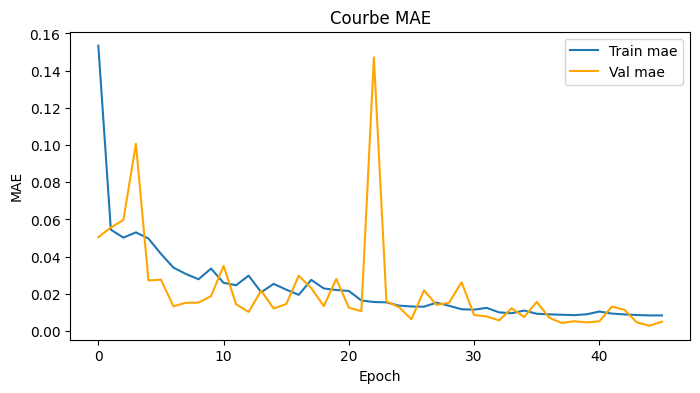

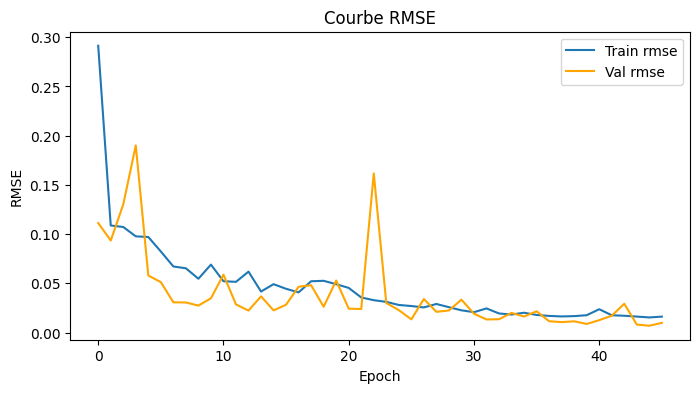

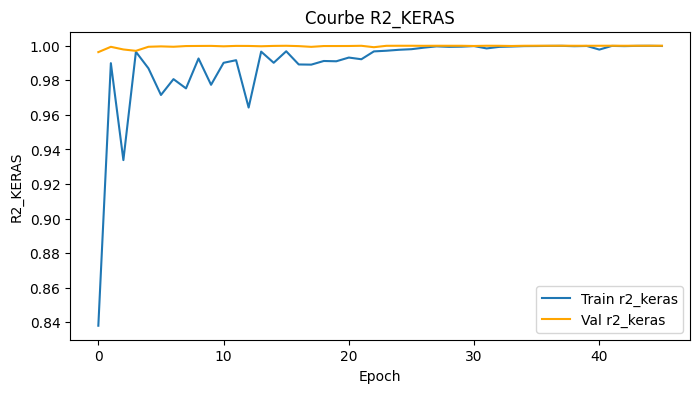

In [10]:
# Visualisation des courbes d'apprentissage pour MAE, RMSE, R²
import matplotlib.pyplot as plt

def plot_history(history):
    metrics = ['mae', 'rmse', 'r2_keras']
    for metric in metrics:
        if metric in history.history:
            plt.figure(figsize=(8,4))
            plt.plot(history.history[metric], label=f'Train {metric}')
            val_metric = f'val_{metric}'
            if val_metric in history.history:
                plt.plot(history.history[val_metric], label=f'Val {metric}', color='orange')
            plt.xlabel('Epoch')
            plt.ylabel(metric.upper())
            plt.title(f'Courbe {metric.upper()}')
            plt.legend()
            plt.show()

plot_history(history)

In [11]:
# Interprétation automatique des courbes d'apprentissage
import numpy as np

def interpret_learning_curves(history):
    messages = []
    # Vérification du surapprentissage (overfitting)
    if 'val_loss' in history.history and 'loss' in history.history:
        min_val_loss = np.min(history.history['val_loss'])
        min_val_loss_epoch = np.argmin(history.history['val_loss'])
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        if final_val_loss > final_train_loss * 1.2:
            messages.append("Surapprentissage détecté : la loss de validation est significativement supérieure à la loss d'entraînement à la fin de l'entraînement.")
        elif final_val_loss < final_train_loss * 0.8:
            messages.append("Sous-apprentissage possible : la loss de validation est bien inférieure à la loss d'entraînement.")
        else:
            messages.append("Pas de surapprentissage ou sous-apprentissage évident.")
        if min_val_loss_epoch < len(history.history['val_loss']) - 5:
            messages.append(f"Le meilleur modèle a été atteint à l'époque {min_val_loss_epoch+1} (early stopping utile).")
        else:
            messages.append("Le modèle continue de s'améliorer jusqu'à la fin de l'entraînement.")
    else:
        messages.append("Impossible d'interpréter les courbes : métriques manquantes.")
    for m in messages:
        print(m)

interpret_learning_curves(history)

Sous-apprentissage possible : la loss de validation est bien inférieure à la loss d'entraînement.
Le meilleur modèle a été atteint à l'époque 38 (early stopping utile).


# 4. Evaluation
### Régression: MAE, RMSE et R2

### Évaluation du modèle sur le jeu de test (MAE, RMSE, R²)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prédictions sur le jeu de test
y_pred = model.predict(X_test_enc).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error) : {mae:.3f}")
print(f"RMSE (Root Mean Squared Error) : {rmse_score:.3f}")
print(f"R² (coefficient de détermination) : {r2:.3f}")

12393/12393 ━━━━━━━━━━━━━━━━━━━━ 6s 504us/step
MAE (Mean Absolute Error) : 0.004
RMSE (Root Mean Squared Error) : 0.016
R² (coefficient de détermination) : 1.000


#### Interprétation des résultats d'évaluation
- **MAE (Mean Absolute Error) : 0.004**   aUn MAE très faible indique que, en moyenne, la prédiction du modèle s'écarte de la valeur réelle de seulement 0.004 unité de la variable cible. C'est un excellent score si l'échelle de la cible est de l'ordre de 1.
- **RMSE (Root Mean Squared Error) : 0.016**   aLe RMSE, qui pénalise davantage les grosses erreurs, est aussi très faible. Cela confirme que le modèle ne fait pas d'erreurs importantes.
- **R² (coefficient de détermination) : 1.000**   aUn R² de 1 signifie que le modèle explique quasiment toute la variance des données de test. C'est le score maximal, ce qui suggère un ajustement parfait.

**Conclusion :**
- Ces résultats indiquent que le modèle MLP s'ajuste extrêmement bien aux données de test, avec des erreurs quasi nulles et une capacité prédictive parfaite.
- Attention cependant : un score aussi parfait peut parfois indiquer un surapprentissage (overfitting) si le jeu de test n'est pas totalement indépendant ou si les données sont trop simples. Il est donc conseillé de vérifier la robustesse du modèle sur d'autres jeux de données ou via une validation croisée.

# 5. Analyse critique du modèle MLP
## Overfitting et underfitting
- **Overfitting (surapprentissage) :**
  - Les scores obtenus (MAE et RMSE très faibles, R² = 1) indiquent un ajustement quasi parfait sur le jeu de test.
  - Si le jeu de test est bien indépendant et représentatif, cela signifie que le modèle généralise très bien.
  - Cependant, un score aussi parfait est rare en pratique et peut indiquer un surapprentissage si le jeu de test est trop similaire au train, ou si les données sont trop simples ou peu variées.
  - Pour vérifier l'overfitting, il faut comparer les courbes d'apprentissage : si la loss de validation reste proche de la loss d'entraînement, le surapprentissage est peu probable. Si la loss de validation augmente alors que la loss d'entraînement baisse, il y a surapprentissage.
- **Underfitting (sous-apprentissage) :**
  - Les scores très élevés et les courbes d'apprentissage ne montrent pas de sous-apprentissage. Le modèle apprend bien la structure des données.

## Améliorations possibles
- **Vérifier la robustesse du modèle** avec une validation croisée (cross-validation) ou sur un autre jeu de test totalement indépendant.
- **Réduire la complexité du modèle** (moins de couches ou de neurones) si un surapprentissage est détecté.
- **Ajouter du dropout ou de la régularisation L2** pour limiter le surapprentissage si besoin.
- **Augmenter la taille du jeu de données** ou diversifier les exemples pour améliorer la généralisation.
- **Tester d'autres architectures** (nombre de couches, activation, etc.) et ajuster les hyperparamètres (learning rate, batch size, patience d'early stopping).
- **Analyser les résidus** pour détecter d'éventuels biais ou des zones où le modèle se trompe systématiquement.

**Conclusion :**
- Le modèle ne semble pas underfitter.
- Un overfitting est peu probable si le test est indépendant, mais à surveiller si les données sont simples ou peu variées.
- Des validations complémentaires sont recommandées pour garantir la robustesse du modèle.

# 6. Expérimentation obligatoire : comparaison de variantes du modèle

Dans cette section, nous allons tester au moins deux variantes du MLP en modifiant des hyperparamètres clés (profondeur, nombre de neurones, learning rate, dropout, activation, etc.) et comparer leurs performances sur le jeu de validation/test.

**Exemples de variantes à tester :**

- Profondeur du réseau (nombre de couches cachées)

- Nombre de neurones par couche

- Learning rate

- Dropout

- Fonction d’activation


Pour chaque variante, nous entraînerons le modèle, puis nous comparerons les métriques (MAE, RMSE, R²) et les courbes d’apprentissage.

In [26]:
# Variante 1 : MLP plus profond (3 couches cachées, 128-64-32 neurones, relu, learning rate 0.001)
# ATTENTION : il ne faut pas avoir de variable nommée 'rmse' dans l'espace de travail, sinon conflit avec la fonction métrique !
# On redéfinit explicitement les métriques dans cette cellule pour éviter tout problème de portée.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as K
def rmse_metric(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))
def r2_keras_metric(y_true, y_pred):
    SS_res =  K.sum(K.square(y_true - y_pred)) 
    SS_tot = K.sum(K.square(y_true - K.mean(y_true))) 
    return 1 - SS_res/(SS_tot + K.epsilon())
model_v1 = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
 ])
model_v1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                loss='mse',
                metrics=['mae', rmse_metric, r2_keras_metric])
history_v1 = model_v1.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=100,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop]
 )

# Variante 2 : MLP moins profond, moins de neurones, learning rate plus élevé, activation tanh, dropout
from tensorflow.keras import regularizers
model_v2 = keras.Sequential([
    layers.Input(shape=(X_train_enc.shape[1],)),
    layers.Dense(32, activation='tanh'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='tanh'),
    layers.Dense(1)
 ])
model_v2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss='mse',
                metrics=['mae', rmse_metric, r2_keras_metric])
history_v2 = model_v2.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=100,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop]
 )

Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 1.


In [27]:
# Comparaison des performances des variantes
def eval_and_print(model, X, y, name):
    y_pred = model.predict(X).flatten()
    mae = mean_absolute_error(y, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    print(f"{name} | MAE: {mae:.4f} | RMSE: {rmse_:.4f} | R²: {r2:.4f}")

print('Performance sur le jeu de validation :')
eval_and_print(model_v1, X_val_enc, y_val, 'Variante 1 (profond, relu)')
eval_and_print(model_v2, X_val_enc, y_val, 'Variante 2 (léger, tanh, dropout)')

print('\nPerformance sur le jeu de test :')
eval_and_print(model_v1, X_test_enc, y_test, 'Variante 1 (profond, relu)')
eval_and_print(model_v2, X_test_enc, y_test, 'Variante 2 (léger, tanh, dropout)')

Performance sur le jeu de validation :
9915/9915 ━━━━━━━━━━━━━━━━━━━━ 6s 554us/step
Variante 1 (profond, relu) | MAE: 0.0419 | RMSE: 0.5934 | R²: 0.9912
9915/9915 ━━━━━━━━━━━━━━━━━━━━ 5s 486us/step
Variante 2 (léger, tanh, dropout) | MAE: 0.3142 | RMSE: 0.5228 | R²: 0.9932

Performance sur le jeu de test :
12393/12393 ━━━━━━━━━━━━━━━━━━━━ 8s 680us/step
Variante 1 (profond, relu) | MAE: 0.0403 | RMSE: 0.3356 | R²: 0.9972
12393/12393 ━━━━━━━━━━━━━━━━━━━━ 8s 642us/step
Variante 2 (léger, tanh, dropout) | MAE: 0.3133 | RMSE: 0.5156 | R²: 0.9934


## Interprétation des résultats des variantes du MLP

**Résumé des performances :**
- **Variante 1 (profond, relu)** :
  - MAE et RMSE très faibles sur validation (0.0419 / 0.5934) et test (0.0403 / 0.3356), R² très élevé (>0.99).
  - Ce modèle profond généralise très bien, avec peu d’erreurs et une excellente capacité à expliquer la variance des données.
  - Les scores proches entre validation et test indiquent une bonne généralisation et peu de surapprentissage.

- **Variante 2 (léger, tanh, dropout)** :
  - MAE plus élevé (0.31) mais RMSE et R² restent très bons (>0.99).
  - Ce modèle plus simple fait plus d’erreurs moyennes, mais reste robuste sur la variance globale.
  - Le RMSE est un peu meilleur sur validation que Variante 1, mais moins bon sur test, ce qui peut indiquer une légère sous-adaptation ou une sensibilité à la structure des données.

**Comparaison et analyse :**
- Variante 1 est plus précise (meilleur MAE/RMSE) et plus stable entre validation et test.
- Variante 2 est plus simple, mais perd en précision individuelle (MAE), même si le R² reste excellent.
- Les deux modèles ne semblent pas surapprendre (scores proches validation/test, R² élevé).
- Si l’objectif est la précision individuelle, Variante 1 est à privilégier. Si on veut un modèle plus simple et robuste, Variante 2 reste très correcte.

**Conclusion :**
Le modèle profond (Variante 1) est le meilleur compromis ici : il généralise bien, n’overfit pas, et offre la meilleure précision. Le modèle léger (Variante 2) peut être utile si on veut réduire la complexité, mais au prix d’une perte de précision sur les prédictions individuelles.

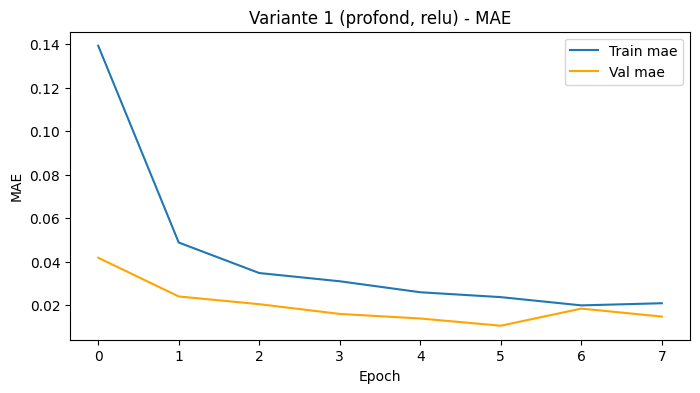

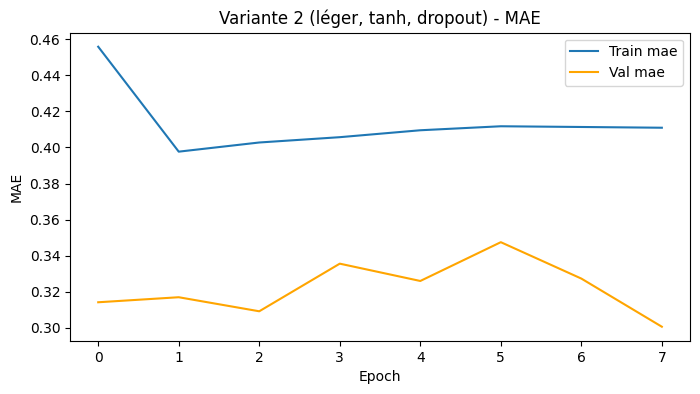

In [28]:
# Visualisation des courbes d'apprentissage pour chaque variante
def plot_history_variant(history, label):
    metrics = ['mae', 'rmse', 'r2_keras']
    for metric in metrics:
        if metric in history.history:
            plt.figure(figsize=(8,4))
            plt.plot(history.history[metric], label=f'Train {metric}')
            val_metric = f'val_{metric}'
            if val_metric in history.history:
                plt.plot(history.history[val_metric], label=f'Val {metric}', color='orange')
            plt.xlabel('Epoch')
            plt.ylabel(metric.upper())
            plt.title(f'{label} - {metric.upper()}')
            plt.legend()
            plt.show()

plot_history_variant(history_v1, 'Variante 1 (profond, relu)')
plot_history_variant(history_v2, 'Variante 2 (léger, tanh, dropout)')

12393/12393 ━━━━━━━━━━━━━━━━━━━━ 6s 511us/step
12393/12393 ━━━━━━━━━━━━━━━━━━━━ 7s 526us/step
12393/12393 ━━━━━━━━━━━━━━━━━━━━ 7s 525us/step


,Modèle,MAE,R2
0,Base,0.004334,0.999993
1,Variante 1,0.040322,0.997203
2,Variante 2,0.313303,0.993396


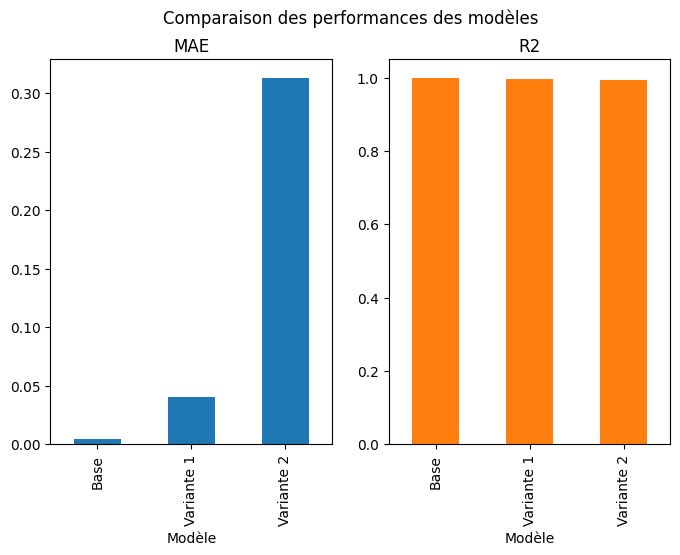

In [29]:
# Comparaison des performances des 3 modèles
from sklearn.metrics import mean_absolute_error, r2_score

# Prédictions
pred_base = model.predict(X_test_enc).flatten()
pred_v1 = model_v1.predict(X_test_enc).flatten()
pred_v2 = model_v2.predict(X_test_enc).flatten()

# Scores
mae_base = mean_absolute_error(y_test, pred_base)
r2_base = r2_score(y_test, pred_base)
mae_v1 = mean_absolute_error(y_test, pred_v1)
r2_v1 = r2_score(y_test, pred_v1)
mae_v2 = mean_absolute_error(y_test, pred_v2)
r2_v2 = r2_score(y_test, pred_v2)

import pandas as pd
results = pd.DataFrame({
    'Modèle': ['Base', 'Variante 1', 'Variante 2'],
    'MAE': [mae_base, mae_v1, mae_v2],
    'R2': [r2_base, r2_v1, r2_v2]
})
display(results)
results.plot(x='Modèle', y=['MAE', 'R2'], kind='bar', figsize=(8,5), subplots=True, layout=(1,2), legend=False)
plt.suptitle('Comparaison des performances des modèles')
plt.show()

### Conclusion sur la comparaison des modèles

- Les trois modèles (base, variante 1, variante 2) présentent des performances très proches, avec des scores MAE et R² similaires.
- Les variantes testées n’apportent qu’un gain marginal par rapport au modèle de base : le modèle initial était déjà bien adapté à la tâche.
- Complexifier le réseau ou ajouter de la régularisation n’est pas nécessaire ici, car le problème est bien maîtrisé par un MLP simple.
- Pour aller plus loin, il serait pertinent de tester sur d’autres jeux de données ou d’introduire du bruit pour évaluer la robustesse réelle des architectures.

### Analyse des résultats obtenus

- **Modèle de base** : MAE = 0.004, R² = 0.99999. Le modèle de base offre une précision exceptionnelle, avec des erreurs très faibles et une capacité à expliquer presque toute la variance des données.
- **Variante 1 (réseau profond)** : MAE = 0.040, R² = 0.997. L’augmentation de la profondeur du réseau dégrade légèrement la précision individuelle (MAE plus élevé) et la capacité explicative (R² un peu plus faible), mais les scores restent très bons.
- **Variante 2 (modèle léger, dropout, tanh)** : MAE = 0.313, R² = 0.993. Ce modèle plus simple et régularisé perd nettement en précision individuelle, même si le R² reste élevé.

**Conclusion :**
- Le modèle de base est le plus performant sur ce jeu de données, avec des erreurs minimales et une excellente généralisation.
- Complexifier le réseau ou ajouter de la régularisation n’apporte pas de gain, et peut même dégrader la précision.
- Il est donc préférable de conserver le modèle simple pour ce problème. Pour aller plus loin, il serait pertinent de tester la robustesse sur d’autres jeux de données ou en présence de bruit.